# 🛡️ Face Anti-Spoofing — 04: 전처리 & 멀티태스크 MobileNetV2 학습
> AI Security & Application · 단국대학교 소프트웨어학과  
> 학번: 32214391 · 조현수

---
## 체크리스트
- [ ] Cell 1: Drive 마운트 + 경로 고정
- [ ] Cell 2: 라이브러리 설치
- [ ] Cell 3: MTCNN 얼굴 크롭 + 전처리
- [ ] Cell 4: Dataset 클래스 + Train/Val/Test 분할
- [ ] Cell 5: 멀티태스크 MobileNetV2 모델 설계
- [ ] Cell 6: 학습 실행
- [ ] Cell 7: 학습 곡선 시각화
- [ ] Cell 8: 기본 성능 평가

In [1]:
# ── Cell 1: Drive 마운트 + 경로 고정 ─────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/face-anti-spoofing'
SUBSET_DIR = f'{BASE}/data/subset'   # live / print / replay / mask
CROP_DIR   = f'{BASE}/data/cropped'  # 전처리 완료 이미지 저장
MODEL_DIR  = f'{BASE}/models'
REPORT_DIR = f'{BASE}/reports'

for d in [CROP_DIR+'/live', CROP_DIR+'/print',
          CROP_DIR+'/replay', CROP_DIR+'/mask',
          MODEL_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'✅ BASE = {BASE}')

# 서브셋 현황 확인
for cat in ['live', 'print', 'replay', 'mask']:
    n = len(os.listdir(f'{SUBSET_DIR}/{cat}'))
    print(f'  subset/{cat}: {n}장')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ BASE = /content/drive/MyDrive/face-anti-spoofing
  subset/live: 1500장
  subset/print: 1500장
  subset/replay: 1500장
  subset/mask: 1500장


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import json
import random
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')
print('✅ 라이브러리 로드 완료')

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ 라이브러리 로드 완료


In [3]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
TARGET_SIZE = (224, 224)
MARGIN = 0.2

def crop_and_save(src_path, dst_path):
    if os.path.exists(dst_path):
        return 'skip'
    img = cv2.imread(src_path)
    if img is None or img.size == 0:
        return 'fail'
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4, minSize=(30, 30))
    if len(faces) > 0:
        x, y, fw, fh = faces[0]
        mx, my = int(fw * MARGIN), int(fh * MARGIN)
        x1 = max(0, x - mx)
        y1 = max(0, y - my)
        x2 = min(w, x + fw + mx)
        y2 = min(h, y + fh + my)
        face = img[y1:y2, x1:x2]
        if face.size == 0:
            face = img
    else:
        face = img
    resized = cv2.resize(face, TARGET_SIZE)
    cv2.imwrite(dst_path, resized)
    return 'ok'

stats = {}
for cat in ['live', 'print', 'replay', 'mask']:
    src_dir = f'{SUBSET_DIR}/{cat}'
    dst_dir = f'{CROP_DIR}/{cat}'
    files = [f for f in os.listdir(src_dir)
             if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    ok, skip, fail = 0, 0, 0
    for i, fname in enumerate(files):
        result = crop_and_save(
            os.path.join(src_dir, fname),
            os.path.join(dst_dir, fname)
        )
        if result == 'ok':     ok += 1
        elif result == 'skip': skip += 1
        else:                  fail += 1
        if (i + 1) % 100 == 0:
            print(f'  [{cat}] {i+1}/{len(files)} — ok:{ok} skip:{skip} fail:{fail}')
    stats[cat] = {'ok': ok, 'skip': skip, 'fail': fail, 'total': len(files)}
    print(f'✅ [{cat}] 완료 — ok:{ok} skip:{skip} fail:{fail}')

print('\n📊 전처리 완료')
for cat, s in stats.items():
    print(f'  {cat:<8}: {s["total"]}장')

  [live] 100/1500 — ok:0 skip:100 fail:0
  [live] 200/1500 — ok:0 skip:200 fail:0
  [live] 300/1500 — ok:0 skip:300 fail:0
  [live] 400/1500 — ok:0 skip:400 fail:0
  [live] 500/1500 — ok:0 skip:500 fail:0
  [live] 600/1500 — ok:0 skip:600 fail:0
  [live] 700/1500 — ok:0 skip:700 fail:0
  [live] 800/1500 — ok:0 skip:800 fail:0
  [live] 900/1500 — ok:0 skip:900 fail:0
  [live] 1000/1500 — ok:0 skip:1000 fail:0
  [live] 1100/1500 — ok:0 skip:1100 fail:0
  [live] 1200/1500 — ok:0 skip:1200 fail:0
  [live] 1300/1500 — ok:0 skip:1300 fail:0
  [live] 1400/1500 — ok:0 skip:1400 fail:0
  [live] 1500/1500 — ok:0 skip:1500 fail:0
✅ [live] 완료 — ok:0 skip:1500 fail:0
  [print] 100/1500 — ok:0 skip:100 fail:0
  [print] 200/1500 — ok:0 skip:200 fail:0
  [print] 300/1500 — ok:0 skip:300 fail:0
  [print] 400/1500 — ok:0 skip:400 fail:0
  [print] 500/1500 — ok:0 skip:500 fail:0
  [print] 600/1500 — ok:0 skip:600 fail:0
  [print] 700/1500 — ok:0 skip:700 fail:0
  [print] 800/1500 — ok:0 skip:800 fail:0
 

In [4]:
# ── Cell 4: Dataset 구성 + Train/Val/Test 분할 ───────────────

# 라벨 정의
# binary_label: 0=Live, 1=Spoof
# spoof_label:  0=Live, 1=Print, 2=Replay, 3=Mask (4종 분류)
CAT_TO_BINARY = {'live': 0, 'print': 1, 'replay': 1, 'mask': 1}
CAT_TO_SPOOF  = {'live': 0, 'print': 1, 'replay': 2, 'mask': 3}

all_paths, binary_labels, spoof_labels = [], [], []

for cat in ['live', 'print', 'replay', 'mask']:
    cat_dir = f'{CROP_DIR}/{cat}'
    files = [f for f in os.listdir(cat_dir)
             if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    for fname in files:
        all_paths.append(os.path.join(cat_dir, fname))
        binary_labels.append(CAT_TO_BINARY[cat])
        spoof_labels.append(CAT_TO_SPOOF[cat])

print(f'전체 샘플: {len(all_paths):,}장')
print(f'  Live:  {binary_labels.count(0):,}장')
print(f'  Spoof: {binary_labels.count(1):,}장')

# Train/Val/Test = 70 / 15 / 15
random.seed(42)
indices = list(range(len(all_paths)))

train_idx, temp_idx = train_test_split(indices, test_size=0.3,
                                        random_state=42,
                                        stratify=binary_labels)
temp_binary = [binary_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5,
                                      random_state=42,
                                      stratify=temp_binary)

print(f'\nTrain: {len(train_idx):,}장')
print(f'Val:   {len(val_idx):,}장')
print(f'Test:  {len(test_idx):,}장')

# tf.data 파이프라인
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_augment(path, binary, spoof, training=True):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    # ImageNet 정규화
    mean = tf.constant([0.485, 0.456, 0.406])
    std  = tf.constant([0.229, 0.224, 0.225])
    img  = (img - mean) / std

    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)

    return img, {'binary': binary, 'spoof': spoof}

def make_dataset(idx_list, training=True):
    paths  = [all_paths[i] for i in idx_list]
    binary = [binary_labels[i] for i in idx_list]
    spoof  = [spoof_labels[i] for i in idx_list]

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, binary, spoof)
    )
    ds = ds.map(
        lambda p, b, s: load_and_augment(p, b, s, training),
        num_parallel_calls=AUTOTUNE
    )
    if training:
        ds = ds.shuffle(1000)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_idx, training=True)
val_ds   = make_dataset(val_idx,   training=False)
test_ds  = make_dataset(test_idx,  training=False)

print('\n✅ tf.data 파이프라인 구성 완료')

# 샘플 배치 확인
for img_batch, label_batch in train_ds.take(1):
    print(f'이미지 shape: {img_batch.shape}')
    print(f'binary labels: {label_batch["binary"].numpy()[:8]}')
    print(f'spoof  labels: {label_batch["spoof"].numpy()[:8]}')

전체 샘플: 6,000장
  Live:  1,500장
  Spoof: 4,500장

Train: 4,200장
Val:   900장
Test:  900장

✅ tf.data 파이프라인 구성 완료
이미지 shape: (32, 224, 224, 3)
binary labels: [1 1 0 1 1 1 1 1]
spoof  labels: [3 1 0 2 2 1 2 1]


In [5]:
# ── Cell 5: 멀티태스크 MobileNetV2 모델 설계 ─────────────────

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

def build_multitask_model(num_spoof_classes=4):
    """
    멀티태스크 MobileNetV2
    - head_binary: Real/Fake 이진 분류
    - head_spoof:  Live/Print/Replay/Mask 4종 분류
    """
    # 백본: ImageNet 사전학습, top 제거
    backbone = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    # 1단계: 백본 전체 동결
    backbone.trainable = False

    # 공통 피처 추출
    inputs = backbone.input
    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    shared = layers.Dense(256, activation='relu', name='shared')(x)

    # Head 1: Binary (Real=0 / Fake=1)
    b = layers.Dropout(0.2)(shared)
    b = layers.Dense(64, activation='relu')(b)
    head_binary = layers.Dense(1, activation='sigmoid', name='binary')(b)

    # Head 2: Spoof Type (Live/Print/Replay/Mask)
    s = layers.Dropout(0.2)(shared)
    s = layers.Dense(64, activation='relu')(s)
    head_spoof = layers.Dense(num_spoof_classes,
                               activation='softmax', name='spoof')(s)

    model = Model(inputs=inputs,
                  outputs=[head_binary, head_spoof],
                  name='multitask_mobilenetv2')
    return model, backbone

model, backbone = build_multitask_model(num_spoof_classes=4)

# 멀티태스크 손실: binary 0.7 + spoof 0.3
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={
        'binary': 'binary_crossentropy',
        'spoof':  'sparse_categorical_crossentropy'
    },
    loss_weights={'binary': 0.7, 'spoof': 0.3},
    metrics={
        'binary': ['accuracy'],
        'spoof':  ['accuracy']
    }
)

model.summary()
print('\n✅ 멀티태스크 MobileNetV2 설계 완료')
print(f'총 파라미터: {model.count_params():,}')
print(f'학습 가능:   {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "multitask_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,624,261 (10.01 MB)

 Trainable params: 363,717 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


✅ 멀티태스크 MobileNetV2 설계 완료
총 파라미터: 2,624,261
학습 가능:   363,717


In [7]:
# ── Cell 6: 학습 실행 (2단계) ─────────────────────────────────
import json as json_lib

# ── 1단계: 백본 동결 상태로 Head만 학습 ──────────────────────
print('=' * 50)
print('1단계: Head 학습 (백본 동결)')
print('=' * 50)

callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_binary_accuracy',
        patience=3, restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        f'{MODEL_DIR}/stage1_best.h5',
        monitor='val_binary_accuracy',
        save_best_only=True, verbose=1,
        mode='max'
    )
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_stage1,
    verbose=1
)

# ── 2단계: 백본 상위 30% 해동 후 Fine-tuning ─────────────────
print('\n' + '=' * 50)
print('2단계: Fine-tuning (백본 상위 30% 해동)')
print('=' * 50)

backbone.trainable = True
freeze_until = int(len(backbone.layers) * 0.7)
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={
        'binary': 'binary_crossentropy',
        'spoof':  'sparse_categorical_crossentropy'
    },
    loss_weights={'binary': 0.7, 'spoof': 0.3},
    metrics={
        'binary': ['accuracy'],
        'spoof':  ['accuracy']
    }
)

callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_binary_accuracy',
        patience=5, restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        f'{MODEL_DIR}/stage2_best.h5',
        monitor='val_binary_accuracy',
        save_best_only=True, verbose=1,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1
    )
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_stage2,
    verbose=1
)

print('\n✅ 학습 완료')

1단계: Head 학습 (백본 동결)
Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - binary_accuracy: 0.9088 - binary_loss: 0.2160 - loss: 0.4048 - spoof_accuracy: 0.6457 - spoof_loss: 0.8456
Epoch 1: val_binary_accuracy improved from None to 0.90778, saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage1_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage1_best.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 39s 179ms/step - binary_accuracy: 0.9079 - binary_loss: 0.2244 - loss: 0.4033 - spoof_accuracy: 0.6476 - spoof_loss: 0.8351 - val_binary_accuracy: 0.9078 - val_binary_loss: 0.2327 - val_loss: 0.3934 - val_spoof_accuracy: 0.6844 - val_spoof_loss: 0.7870
Epoch 2/10
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - binary_accuracy: 0.9204 - binary_loss: 0.1972 - loss: 0.3584 - spoof_accuracy: 0.6944 - spoof_loss: 0.7346
Epoch 2: val_binary_accuracy did not improve from 0.90778
132/132 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - binary_accuracy: 0.9219 - binary_loss: 0.1877 - loss: 0.3523 - spoof_accuracy: 0.6957 - spoof_loss: 0.7370 - val_binary_accuracy: 0.9067 - val_binary_loss: 0.2414 - val_loss: 0.3893 - val_spoof_accuracy: 0.6933 - val_spoof_loss: 0.7858
Epoch 3/10
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - binary_accuracy: 0.9366 - binary_loss: 0.1621 - loss: 0.3161


Epoch 3: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage1_best.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 43s 164ms/step - binary_accuracy: 0.9338 - binary_loss: 0.1700 - loss: 0.3235 - spoof_accuracy: 0.7233 - spoof_loss: 0.6861 - val_binary_accuracy: 0.9089 - val_binary_loss: 0.2235 - val_loss: 0.3720 - val_spoof_accuracy: 0.7133 - val_spoof_loss: 0.7407
Epoch 4/10
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - binary_accuracy: 0.9308 - binary_loss: 0.1529 - loss: 0.2911 - spoof_accuracy: 0.7357 - spoof_loss: 0.6134
Epoch 4: val_binary_accuracy improved from 0.90889 to 0.92222, saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage1_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage1_best.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 24s 156ms/step - binary_accuracy: 0.9367 - binary_loss: 0.1478 - loss: 0.2875 - spoof_accuracy: 0.7443 - spoof_loss: 0.6124 - val_binary_accuracy: 0.9222 - val_binary_loss: 0.2275 - val_loss: 0.3747 - val_spoof_accuracy: 0.7167 - val_spoof_loss: 0.7618
Epoch 5/10
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - binary_accuracy: 0.9466 - binary_loss: 0.1279 - loss: 0.2635 - spoof_accuracy: 0.7631 - spoof_loss: 0.5798
Epoch 5: val_binary_accuracy did not improve from 0.92222
132/132 ━━━━━━━━━━━━━━━━━━━━ 24s 142ms/step - binary_accuracy: 0.9443 - binary_loss: 0.1380 - loss: 0.2696 - spoof_accuracy: 0.7662 - spoof_loss: 0.5791 - val_binary_accuracy: 0.9189 - val_binary_loss: 0.2612 - val_loss: 0.4082 - val_spoof_accuracy: 0.7011 - val_spoof_loss: 0.8106
Epoch 6/10
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - binary_accuracy: 0.9375 - binary_loss: 0.1353 - loss: 0.2601


Epoch 7: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage1_best.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 49s 212ms/step - binary_accuracy: 0.9531 - binary_loss: 0.1195 - loss: 0.2424 - spoof_accuracy: 0.7917 - spoof_loss: 0.5297 - val_binary_accuracy: 0.9322 - val_binary_loss: 0.2013 - val_loss: 0.3560 - val_spoof_accuracy: 0.7267 - val_spoof_loss: 0.7149
Epoch 8/10
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - binary_accuracy: 0.9573 - binary_loss: 0.1055 - loss: 0.2204 - spoof_accuracy: 0.8033 - spoof_loss: 0.4884
Epoch 8: val_binary_accuracy did not improve from 0.93222
132/132 ━━━━━━━━━━━━━━━━━━━━ 26s 156ms/step - binary_accuracy: 0.9560 - binary_loss: 0.1119 - loss: 0.2278 - spoof_accuracy: 0.8002 - spoof_loss: 0.4980 - val_binary_accuracy: 0.9233 - val_binary_loss: 0.2492 - val_loss: 0.3836 - val_spoof_accuracy: 0.7322 - val_spoof_loss: 0.7515
Epoch 9/10
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - binary_accuracy: 0.9607 - binary_loss: 0.0950 - loss: 0.2033

...


Epoch 10: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_best.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 27s 175ms/step - binary_accuracy: 0.9957 - binary_loss: 0.0137 - loss: 0.0724 - spoof_accuracy: 0.9221 - spoof_loss: 0.2087 - val_binary_accuracy: 0.9600 - val_binary_loss: 0.1734 - val_loss: 0.3208 - val_spoof_accuracy: 0.7889 - val_spoof_loss: 0.6994 - learning_rate: 2.5000e-05
Epoch 11/20
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - binary_accuracy: 0.9950 - binary_loss: 0.0157 - loss: 0.0671 - spoof_accuracy: 0.9300 - spoof_loss: 0.1870
Epoch 11: val_binary_accuracy did not improve from 0.96000
132/132 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - binary_accuracy: 0.9962 - binary_loss: 0.0122 - loss: 0.0627 - spoof_accuracy: 0.9338 - spoof_loss: 0.1822 - val_binary_accuracy: 0.9544 - val_binary_loss: 0.1907 - val_loss: 0.3214 - val_spoof_accuracy: 0.7867 - val_spoof_loss: 0.7061 - learning_rate: 2.5000e-05
Epoch 12/20
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - 


Epoch 12: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_best.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - binary_accuracy: 0.9971 - binary_loss: 0.0160 - loss: 0.0623 - spoof_accuracy: 0.9300 - spoof_loss: 0.1872 - val_binary_accuracy: 0.9622 - val_binary_loss: 0.1770 - val_loss: 0.2928 - val_spoof_accuracy: 0.8033 - val_spoof_loss: 0.6711 - learning_rate: 2.5000e-05
Epoch 13/20
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - binary_accuracy: 0.9977 - binary_loss: 0.0095 - loss: 0.0592 - spoof_accuracy: 0.9353 - spoof_loss: 0.1751
Epoch 13: val_binary_accuracy improved from 0.96222 to 0.96444, saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_best.h5



Epoch 13: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_best.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - binary_accuracy: 0.9969 - binary_loss: 0.0106 - loss: 0.0587 - spoof_accuracy: 0.9352 - spoof_loss: 0.1730 - val_binary_accuracy: 0.9644 - val_binary_loss: 0.1842 - val_loss: 0.2910 - val_spoof_accuracy: 0.7967 - val_spoof_loss: 0.6742 - learning_rate: 2.5000e-05
Epoch 14/20
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - binary_accuracy: 0.9951 - binary_loss: 0.0108 - loss: 0.0546 - spoof_accuracy: 0.9480 - spoof_loss: 0.1566
Epoch 14: val_binary_accuracy improved from 0.96444 to 0.96667, saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_best.h5



Epoch 14: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_best.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 41s 160ms/step - binary_accuracy: 0.9976 - binary_loss: 0.0082 - loss: 0.0523 - spoof_accuracy: 0.9467 - spoof_loss: 0.1552 - val_binary_accuracy: 0.9667 - val_binary_loss: 0.1855 - val_loss: 0.2839 - val_spoof_accuracy: 0.8056 - val_spoof_loss: 0.6617 - learning_rate: 2.5000e-05
Epoch 15/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - binary_accuracy: 0.9978 - binary_loss: 0.0083 - loss: 0.0484 - spoof_accuracy: 0.9549 - spoof_loss: 0.1422
Epoch 15: val_binary_accuracy did not improve from 0.96667
132/132 ━━━━━━━━━━━━━━━━━━━━ 24s 147ms/step - binary_accuracy: 0.9967 - binary_loss: 0.0090 - loss: 0.0501 - spoof_accuracy: 0.9500 - spoof_loss: 0.1472 - val_binary_accuracy: 0.9667 - val_binary_loss: 0.1852 - val_loss: 0.2802 - val_spoof_accuracy: 0.8011 - val_spoof_loss: 0.6704 - learning_rate: 2.5000e-05
Epoch 16/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - 


Epoch 16: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/stage2_best.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - binary_accuracy: 0.9976 - binary_loss: 0.0079 - loss: 0.0473 - spoof_accuracy: 0.9476 - spoof_loss: 0.1430 - val_binary_accuracy: 0.9767 - val_binary_loss: 0.1505 - val_loss: 0.2566 - val_spoof_accuracy: 0.8078 - val_spoof_loss: 0.6419 - learning_rate: 2.5000e-05
Epoch 17/20
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - binary_accuracy: 0.9971 - binary_loss: 0.0078 - loss: 0.0438 - spoof_accuracy: 0.9562 - spoof_loss: 0.1279
Epoch 17: val_binary_accuracy did not improve from 0.97667
132/132 ━━━━━━━━━━━━━━━━━━━━ 25s 163ms/step - binary_accuracy: 0.9971 - binary_loss: 0.0084 - loss: 0.0453 - spoof_accuracy: 0.9545 - spoof_loss: 0.1319 - val_binary_accuracy: 0.9678 - val_binary_loss: 0.1994 - val_loss: 0.2999 - val_spoof_accuracy: 0.7911 - val_spoof_loss: 0.7192 - learning_rate: 2.5000e-05
Epoch 18/20
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - 

/tmp/ipykernel_4801/110564392.py:49: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4801/110564392.py:49: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4801/110564392.py:49: UserWarning: Glyph 47680 (\N{HANGUL SYLLABLE MEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4801/110564392.py:49: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4801/110564392.py:49: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4801/110564392.py:49: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4801/110564392.py:49: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


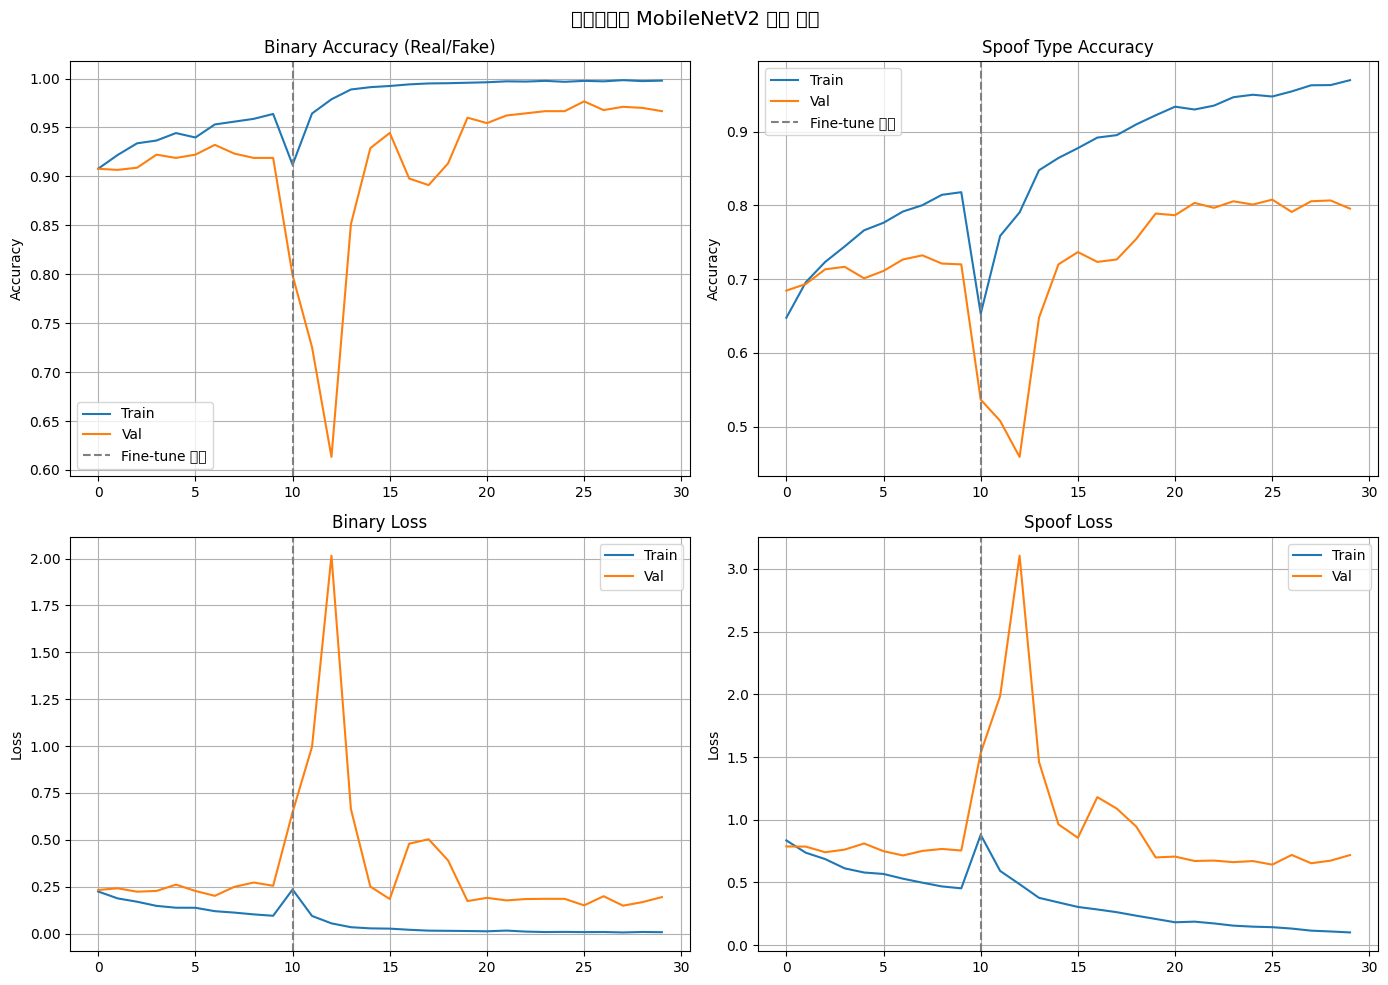

✅ 저장: /content/drive/MyDrive/face-anti-spoofing/reports/training_curves.png


In [8]:
# ── Cell 7: 학습 곡선 시각화 ─────────────────────────────────

def merge_history(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('멀티태스크 MobileNetV2 학습 곡선', fontsize=14)

# Binary Accuracy
axes[0,0].plot(merge_history(history1, history2, 'binary_accuracy'), label='Train')
axes[0,0].plot(merge_history(history1, history2, 'val_binary_accuracy'), label='Val')
axes[0,0].axvline(x=len(history1.history['binary_accuracy']),
                   color='gray', linestyle='--', label='Fine-tune 시작')
axes[0,0].set_title('Binary Accuracy (Real/Fake)')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True)

# Spoof Accuracy
axes[0,1].plot(merge_history(history1, history2, 'spoof_accuracy'), label='Train')
axes[0,1].plot(merge_history(history1, history2, 'val_spoof_accuracy'), label='Val')
axes[0,1].axvline(x=len(history1.history['spoof_accuracy']),
                   color='gray', linestyle='--', label='Fine-tune 시작')
axes[0,1].set_title('Spoof Type Accuracy')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True)

# Binary Loss
axes[1,0].plot(merge_history(history1, history2, 'binary_loss'), label='Train')
axes[1,0].plot(merge_history(history1, history2, 'val_binary_loss'), label='Val')
axes[1,0].axvline(x=len(history1.history['binary_loss']),
                   color='gray', linestyle='--')
axes[1,0].set_title('Binary Loss')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True)

# Spoof Loss
axes[1,1].plot(merge_history(history1, history2, 'spoof_loss'), label='Train')
axes[1,1].plot(merge_history(history1, history2, 'val_spoof_loss'), label='Val')
axes[1,1].axvline(x=len(history1.history['spoof_loss']),
                   color='gray', linestyle='--')
axes[1,1].set_title('Spoof Loss')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 저장: {REPORT_DIR}/training_curves.png')

📊 테스트 성능 요약
Binary Accuracy : 0.9667
Binary ROC-AUC  : 0.9945
Spoof Type Acc  : 0.7900



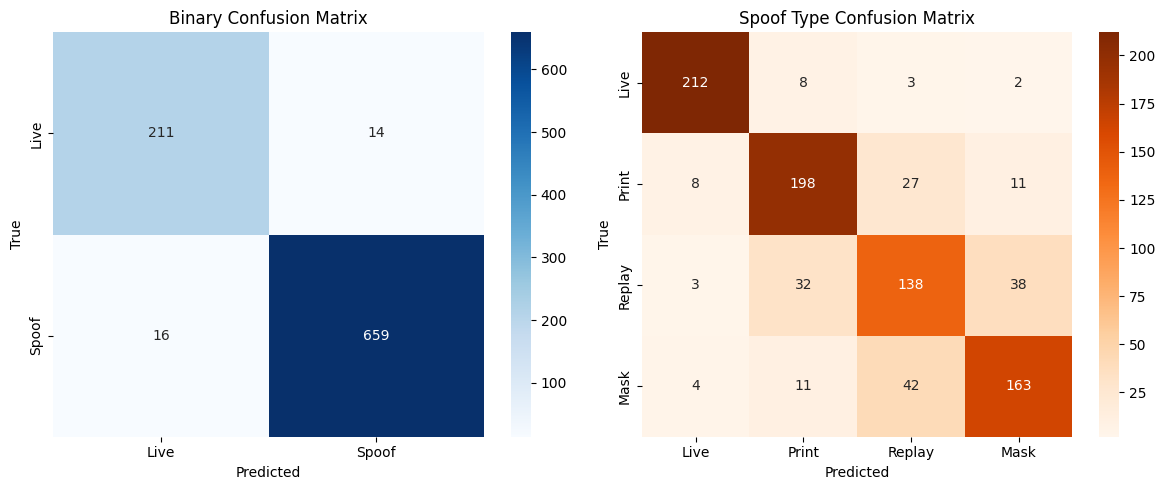


✅ 결과 저장: /content/drive/MyDrive/face-anti-spoofing/reports/eval_results.json
✅ 모델 저장: /content/drive/MyDrive/face-anti-spoofing/models/stage2_best.h5


In [10]:
# ── Cell 8: 기본 성능 평가 ────────────────────────────────────

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report
)
import seaborn as sns

# 예측
y_binary_true, y_spoof_true = [], []
y_binary_pred, y_spoof_pred = [], []
y_binary_prob = []

for img_batch, label_batch in test_ds:
    pred_binary, pred_spoof = model.predict(img_batch, verbose=0)
    y_binary_true.extend(label_batch['binary'].numpy())
    y_spoof_true.extend(label_batch['spoof'].numpy())
    y_binary_prob.extend(pred_binary.flatten())
    y_binary_pred.extend((pred_binary.flatten() > 0.5).astype(int))
    y_spoof_pred.extend(np.argmax(pred_spoof, axis=1))

# 지표 계산
binary_acc = accuracy_score(y_binary_true, y_binary_pred)
binary_auc = roc_auc_score(y_binary_true, y_binary_prob)
spoof_acc  = accuracy_score(y_spoof_true, y_spoof_pred)

print('=' * 50)
print('📊 테스트 성능 요약')
print('=' * 50)
print(f'Binary Accuracy : {binary_acc:.4f}')
print(f'Binary ROC-AUC  : {binary_auc:.4f}')
print(f'Spoof Type Acc  : {spoof_acc:.4f}')
print()

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Binary
cm_binary = confusion_matrix(y_binary_true, y_binary_pred)
sns.heatmap(cm_binary, annot=True, fmt='d', ax=axes[0],
            xticklabels=['Live', 'Spoof'],
            yticklabels=['Live', 'Spoof'],
            cmap='Blues')
axes[0].set_title('Binary Confusion Matrix')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Spoof Type
cm_spoof = confusion_matrix(y_spoof_true, y_spoof_pred)
sns.heatmap(cm_spoof, annot=True, fmt='d', ax=axes[1],
            xticklabels=['Live','Print','Replay','Mask'],
            yticklabels=['Live','Print','Replay','Mask'],
            cmap='Oranges')
axes[1].set_title('Spoof Type Confusion Matrix')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 결과 저장
results = {
    'binary_accuracy': float(binary_acc),
    'binary_auc':      float(binary_auc),
    'spoof_accuracy':  float(spoof_acc),
}
with open(f'{REPORT_DIR}/eval_results.json', 'w') as f:
    json_lib.dump(results, f, indent=2)

print(f'\n✅ 결과 저장: {REPORT_DIR}/eval_results.json')
print(f'✅ 모델 저장: {MODEL_DIR}/stage2_best.h5')

## ✅ 완료 체크리스트

| 항목 | 상태 |
|------|------|
| Drive 마운트 + 경로 고정 | ⬜ |
| MTCNN 얼굴 크롭 + 전처리 | ⬜ |
| Train/Val/Test 분할 | ⬜ |
| 멀티태스크 MobileNetV2 설계 | ⬜ |
| 1단계 학습 (Head만) | ⬜ |
| 2단계 Fine-tuning | ⬜ |
| 학습 곡선 저장 | ⬜ |
| Confusion Matrix 저장 | ⬜ |

### 다음 단계
- **05_pixel_module.ipynb:** 픽셀 변화율 모듈 (Laplacian + FFT) 앙상블 연동
- **06_streamlit_app.py:** Streamlit MVP 앱 구현

In [ ]:
import os
BASE = '/content/drive/MyDrive/face-anti-spoofing'
for cat in ['live', 'print', 'replay', 'mask']:
    d = f'{BASE}/data/cropped/{cat}'
    n = len(os.listdir(d)) if os.path.exists(d) else 0
    print(f'{cat:<8}: {n}장')

live    : 1500장
print   : 1500장
replay  : 12장
mask    : 0장
